### Assignment 1 code to run

In [1]:
import math
# -----------------------------
# Parameters
# -----------------------------
gamma = 0.9
lam=0.5 # used in poisson distribution
xi1, xi2 = 5, 7

# Location states
DEPOT = 0
AT_1 = 1   # engineer is @ machine 1
AT_2 = 2   # engineer is @ machine 2
REP_1 = 3   # 1 unit of remaining time for corrective maintenance @1. Note that this state only exists when x1=xi1. 
REP_2 = 4   # 1 unit of remaining time for corrective maintenance @2. Note that this state only exists when x2=xi2. 

# -----------------------------
# State space
# -----------------------------

# NOTE: we keep only states that are possible

states = []

for x1 in range(xi1 + 1):
    for x2 in range(xi2 + 1):

        # always allowed locations
        for l in [DEPOT, AT_1, AT_2]:
            states.append((x1, x2, l))

        # corrective maintenance state for machine 1
        if x1 == xi1:
            states.append((x1, x2, REP_1))

        # corrective maintenance state for machine 2
        if x2 == xi2:
            states.append((x1, x2, REP_2))


# -----------------------------
# Poisson probabilities
# -----------------------------
def poisson_pmf(y,lam, max_y):
    """
    Returns the y-th element of the list:
    [P(X=0), P(X=1), ..., P(X=max_y-1), P(X>=max_y)]
    with X ~ Poisson(lam)
    """

    probs = []

    if max_y>0:
        # P(X=0)
        p = math.exp(-lam)
        probs.append(p)

        # Compute P(X=k) recursively
        for k in range(1, max_y):
            p = p * lam / k
            probs.append(p)

        # Tail probability
        tail = 1.0 - sum(probs)
        probs.append(tail)
    elif max_y==0:
        probs=[1]
    return probs[y]

# -----------------------------
# Action space
# -----------------------------
#Note that this is further refined below when considering the possible acitons
ACTIONS = ["nothing", "travel_1", "travel_2", "travel_depot",
           "maintain_1", "maintain_2", "continue maintenance"]


"""
The action "continue maintenance" is a pseudo-action to only indicate that we are forced to continue the corrective maintenance for a second period of time and should not impact the results        
"""    

# -----------------------------
# Feasible actions
# -----------------------------

# used in e-gridy!!!

def feasible_actions(state): 
    # based on a state gets me a function of feasible actions! 
    x1, x2, l = state
    
    acts = []
    
    # forced continuation during repair
    if l in (REP_1, REP_2):
        acts = ["continue maintenance"]

    elif l == DEPOT:
        if x2 == xi2 and x1 == xi1:
            acts = ["travel_1", "travel_2"]
        elif x2 == xi2 and x1 < xi1:
            acts = ["travel_2"]
        elif x1 == xi1 and x2 < xi2:
            acts = ["travel_1"]
        else:
            acts = ["nothing", "travel_1", "travel_2"]

    elif l == AT_1:
        if x1 == xi1:
            acts = ["maintain_1"]
        elif x1 < xi1 and x2 == xi2: 
            acts = ["travel_depot"]
        else:
            acts = ["travel_depot", "maintain_1","nothing"]  
        

    elif l == AT_2:
        if x2 == xi2:
            acts = ["maintain_2"]
        elif x2 < xi2 and x1 == xi1: 
            acts = ["travel_depot"]
        else:
            acts = ["travel_depot", "maintain_2","nothing"] 

    return acts

# -----------------------------
# Cost
# -----------------------------
def cost(state, action):
    x1, x2, l = state

    c = 0

    if action == "maintain_1":
        if x1 < xi1:
            c += 1 
        else:
            c += 5 
                
    if action == "maintain_2":
        if x2 < xi2:
            c += 1 
        else:
            c += 5 

    # unavailability cost
    if x1 == xi1 :
        c += 1
    if x2 == xi2 :
        c += 1

    return c


# -----------------------------
# Transitions
# -----------------------------
def transitions(state, action):
    x1, x2, l = state
    trans = {}

    # ---------------- forced repair completion
    if l == REP_1:
        # in the next unit, maintenance completed → machine 1 becomes healthy
        for y in range(xi2-x2+1):
            p = poisson_pmf(y,lam, xi2-x2)
            x2n = min(x2 + y, xi2)
            trans[(0, x2n, AT_1)] = \
                trans.get((0, x2n, AT_1), 0) + p
        return trans

    elif l == REP_2:
        # in the next unit, maintenance completed → machine 2 becomes healthy
        for y in range(xi1-x1+1):
            p = poisson_pmf(y,lam,xi1-x1)
            x1n = min(x1 + y, xi1)
            trans[(x1n, 0, AT_2)] = \
                trans.get((x1n, 0, AT_2), 0) + p
        return trans

    # ---------------- travel
    elif action == "travel_1":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, AT_1)] = \
                    trans.get((x1n, x2n, AT_1), 0) + p
        return trans

    elif action == "travel_2":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, AT_2)] = \
                    trans.get((x1n, x2n, AT_2), 0) + p
        return trans
    
    elif action == "travel_depot":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, DEPOT)] = \
                    trans.get((x1n, x2n, DEPOT), 0) + p

    # ---------------- maintenance start
    elif action == "maintain_1":
        # preventive = 1 period
        if x1 < xi1:
            for y in range(xi2-x2+1):
                p = poisson_pmf(y,lam, xi2-x2)
                x2n = min(x2 + y, xi2)
                trans[(0, x2n, AT_1)] = \
                    trans.get((0, x2n, AT_1), 0) + p
        elif x1 == xi1:
            # corrective = 2 periods
            for y in range(xi2-x2+1):
                p = poisson_pmf(y,lam,xi2-x2)
                x2n = min(x2 + y, xi2)
                trans[(xi1, x2n, REP_1)] = \
                    trans.get((xi1, x2n, REP_1), 0) + p
        return trans

    elif action == "maintain_2":
        if x2 < xi2:
            for y in range(xi1-x1+1):
                p = poisson_pmf(y,lam,xi1-x1)
                x1n = min(x1 + y, xi1)
                trans[(x1n, 0, AT_2)] = \
                    trans.get((x1n, 0, AT_2), 0) + p
        elif x2==xi2:
            for y in range(xi1-x1+1):
                p = poisson_pmf(y,lam,xi1-x1)
                x1n = min(x1 + y, xi1)
                trans[(x1n, xi2, REP_2)] = \
                    trans.get((x1n, xi2, REP_2), 0) + p
        return trans

    elif action == "nothing":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, l)] = \
                    trans.get((x1n, x2n, l), 0) + p
    return trans

# Assignment 2 — Task 3: Q-Learning with Linear Value Function Approximation

This notebook adapts the Q-Learning implementation from Task 1 to use **linear value function approximation (linear VFA)**. Instead of maintaining a full Q-table with one independent entry per feasible $(s,a)$ pair, we approximate the action-value function as:

$$\hat{q}(s, a, \mathbf{w}) = \mathbf{x}(s,a)^\top \mathbf{w}$$

where $\mathbf{x}(s,a)$ is a **table-lookup indicator** (one-hot) feature vector and $\mathbf{w}$ is a flat weight vector of length $|S| \times |A|$. Because $\mathbf{x}(s,a)$ has a single 1 at position $\text{idx}(s,a) = |A| \cdot s_\text{idx} + a_\text{idx}$, the linear approximator collapses to $\hat{q}(s,a,\mathbf{w}) = w[\text{idx}(s,a)]$ — each weight **is** the Q-value for its pair. The SGD update then touches exactly one weight per step, making the algorithm algebraically identical to tabular Q-learning while being formally expressed in the VFA framework.

**Notebook structure:**
1. Policy Iteration oracle (ground-truth $V^*$)
2. Feature vector design and justification
3. Linear VFA Q-Learning: pseudocode and implementation
4. Training run with motivated hyperparameters and convergence analysis
5. Optimal policy extraction and comparison with Assignment 1 (PI)
6. Hyperparameter sensitivity study
7. Comparison with Task 1 (Q-Learning)

---
**Prerequisites:** Execute the Assignment 1 MDP definition cell before running this notebook.
Required in scope: `states`, `ACTIONS`, `feasible_actions`, `cost`, `transitions`,
`gamma`, `xi1`, `xi2`, `DEPOT`, `AT_1`, `AT_2`, `REP_1`, `REP_2`.

In [2]:
import numpy as np
import random
import math
import pandas as pd
import os
import json as _json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Episode length (identical derivation to Task 1) ──────────────────────
def getLengthEpisode(gamma_val=0.9, r_max=7.0, error=1e-8):
    return int(np.ceil(
        np.log(error * (1.0 - gamma_val) / r_max) / np.log(gamma_val)
    ))

T_MAX = getLengthEpisode(gamma_val=gamma)
print(f"Episode length: T_MAX = {T_MAX} steps  (gamma={gamma}, R_max=7, error=1e-8)")

# ── Caches (same as Task 1) ───────────────────────────────────────────────
feasible_cache = {s: feasible_actions(s) for s in states}

cost_cache = {(s, a): cost(s, a) for s in states for a in feasible_cache[s]}

trans_cache = {}
for s in states:
    for a in feasible_cache[s]:
        td    = transitions(s, a)
        p_arr = np.array(list(td.values()), dtype=np.float64)
        p_arr /= p_arr.sum()
        trans_cache[(s, a)] = (list(td.keys()), p_arr)

print(f"Cached {len(trans_cache)} feasible (state, action) distributions")
print(f"States: {len(states)},  Actions: {len(ACTIONS)}")

Episode length: T_MAX = 216 steps  (gamma=0.9, R_max=7, error=1e-8)
Cached 369 feasible (state, action) distributions
States: 158,  Actions: 7


## 1 — Policy Iteration Oracle

Policy Iteration is run with full model knowledge to obtain $V^*(s)$ and $\pi^*(s)$.
These serve two purposes:
- **Oracle MSE**: objective measure of how close the learned $\hat{q}$ converges to $q^*$
- **Policy comparison**: verifying that linear VFA Q-Learning recovers the same decisions

In a real model-free setting this oracle would not be available.
It is used here because the model is known from Assignment 1.

In [3]:
V_PI     = {s: 0.0             for s in states}
policy_PI = {s: feasible_actions(s)[0] for s in states}


def _pi_eval(pol, V, tol=1e-10):
    while True:
        delta = 0.0
        for s in states:
            a     = pol[s]
            v_new = cost(s, a) + gamma * sum(
                p * V[sp] for sp, p in transitions(s, a).items()
            )
            delta = max(delta, abs(V[s] - v_new))
            V[s]  = v_new
        if delta < tol:
            break


def _pi_improve(pol, V):
    stable = True
    for s in states:
        old_a            = pol[s]
        best_a, best_q   = old_a, float("inf")
        for a in feasible_actions(s):
            q = cost(s, a) + gamma * sum(
                p * V[sp] for sp, p in transitions(s, a).items()
            )
            if q < best_q:
                best_q, best_a = q, a
        if best_a != old_a:
            pol[s] = best_a
            stable = False
    return stable


_pi_iters = 0
while True:
    _pi_iters += 1
    _pi_eval(policy_PI, V_PI)
    if _pi_improve(policy_PI, V_PI):
        break

print(f"PI converged in {_pi_iters} iterations")
print(f"V*(0,0,DEPOT) = {V_PI[(0, 0, DEPOT)]:.4f}")
print(f"V*(5,7,DEPOT) = {V_PI[(5, 7, DEPOT)]:.4f}  (worst degradation state)")

PI converged in 5 iterations
V*(0,0,DEPOT) = 2.4620
V*(5,7,DEPOT) = 16.8511  (worst degradation state)


## 2 — Feature Vector Design

### From Q-Table to Linear Approximation

In Task 1, the action-value function was stored as a lookup table: one independent number $Q(s,a)$ per feasible $(s,a)$ pair (a 2D array of shape $|S| \times |A|$). Linear VFA replaces this with a parametric approximation:

$$\hat{q}(s, a, \mathbf{w}) = \mathbf{x}(s,a)^\top \mathbf{w}$$

where $\mathbf{x}(s,a) \in \mathbb{R}^n$ is a feature vector and $\mathbf{w} \in \mathbb{R}^n$ is a shared weight vector updated by stochastic gradient descent.

### Feature Vector: Table-Lookup Indicators

We use the **table-lookup (indicator) feature**, the simplest and most principled choice for this problem. The feature vector for $(s, a)$ is a one-hot vector of length $|S| \times |A|$:

$$\mathbf{x}(s, a) \in \mathbb{R}^{|S| \times |A|}, \qquad x_k(s,a) = \mathbf{1}\bigl(k = |A| \cdot s_\text{idx} + a_\text{idx}\bigr)$$

with a single 1 at the flat index $\text{idx}(s,a) = |A| \cdot s_\text{idx} + a_\text{idx}$ and zeros everywhere else. Infeasible $(s,a)$ pairs are never visited and their weights are set to $+\infty$.

This is the approach explicitly described by the lecturer for OR/maintenance settings:

> *"Instead of having some mapping, I just give it value 1 if my state is actually the first one or if it is the second and so on and so forth. [...] In the context where our feature vector is nothing else than basically ones and zeros, then the only thing that we're doing is renaming $V_0$ into $w_1$ and so on and so forth."*

### Key Simplification

Because $\mathbf{x}(s,a)$ is one-hot, the linear approximator collapses to:

$$\hat{q}(s, a, \mathbf{w}) = \mathbf{x}(s,a)^\top \mathbf{w} = w[\text{idx}(s,a)]$$

The weight at position $\text{idx}(s,a)$ **is** the Q-value for that pair. The gradient is $\nabla_\mathbf{w} \hat{q} = \mathbf{x}(s,a)$, so the SGD update becomes:

$$w[\text{idx}(s,a)] \leftarrow w[\text{idx}(s,a)] + \alpha_k \cdot \underbrace{\bigl[r + \gamma \min_{a'} w[\text{idx}(s',a')] - w[\text{idx}(s,a)]\bigr]}_{\delta \text{ (TD error)}}$$

Exactly one weight changes per step. This is algebraically identical to the tabular Q-learning update in Task 1; the only structural difference is that $Q[s_\text{idx}, a_\text{idx}]$ (2D array) is replaced by $w[|A| \cdot s_\text{idx} + a_\text{idx}]$ (flat vector).

### Learning Rate: Robbins-Monro Per Pair

With table-lookup features, each weight $w[\text{idx}(s,a)]$ is updated only when $(s,a)$ is visited. The per-pair visit counter $N(s,a)$ therefore counts exactly the number of times that weight has been modified, and the Robbins-Monro schedule

$$\alpha_k = \frac{1}{N(s,a)^\omega}, \qquad \omega \in (0.5, 1]$$

applies directly — identical to Task 1. The only new hyperparameter relative to Task 1 is $\omega$ (the decay exponent).

### Convergence Note

From the lecture convergence table, off-policy TD (Q-Learning) with **non-tabular** linear features has no guaranteed convergence. However, with table-lookup features the approximation error is zero and the update rule reduces exactly to the tabular case, so GLIE + Robbins-Monro convergence guarantees carry over.

In [4]:
# ── Index helpers ─────────────────────────────────────────────────────────
# Table-lookup feature: x(s,a) is one-hot of length |S|*|A|.
# Because x is one-hot: Q̂(s,a,w) = w[idx(s,a)].
# Index convention: idx(s,a) = N_ACTIONS * s_idx + a_idx

N_STATES  = len(states)
N_ACTIONS = len(ACTIONS)
W_SIZE    = N_STATES * N_ACTIONS          # length of the flat weight vector


def sa_index(s_idx, a_idx):
    """Flat index into weight vector w for state index s_idx, action index a_idx."""
    return N_ACTIONS * s_idx + a_idx


# Pre-compute, for each state, the flat w-indices of its feasible actions.
# Used for: argmin during exploitation, next-state value look-up, policy extraction.
feasible_flat_global = {}
for _s_idx, _s in enumerate(states):
    feasible_flat_global[_s] = np.array(
        [sa_index(_s_idx, actions_indexes[_a]) for _a in feasible_cache[_s]]
    )

print(f"States: {N_STATES},  Actions: {N_ACTIONS},  Weight vector size: {W_SIZE}")
print(f"Example idx((0,0,DEPOT), 'nothing'): "
      f"{sa_index(states_indexes[(0,0,DEPOT)], actions_indexes['nothing'])}")
print(f"Feasible flat indices for (0,0,DEPOT): {feasible_flat_global[(0,0,DEPOT)]}")

Feature vector dimension: 14
Example phi((0,0,DEPOT), 'nothing'):
[0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


## 3 — Linear VFA Q-Learning

### Pseudocode

```
INPUT  : K (max episodes), omega (R-M exponent), eps_0 (exploration scale)
DERIVE : T_max = ceil( log(error*(1-gamma)/R_max) / log(gamma) )
INIT   : w[i]           <- +inf   for all i in 0..|S|*|A|-1   (infeasible)
         w[idx(s,a)]    <- 0.0    for all feasible (s,a)
         N[idx(s,a)]    <- 1      for all feasible (s,a)       (visit counter, init 1)
         consec         <- 0

FOR k = 0, 1, ..., K-1:
    w_prev <- w[feasible]            copy only feasible weights
    s      <- Uniform(S)             random start state
    eps_k  <- eps_0 / (k + 1)       GLIE exploration rate

    FOR t = 0, 1, ..., T_max - 1:
        flat_s <- feasible flat indices for s

        IF U[0,1] < eps_k:
            a <- uniform random from feasible_actions(s)                 (explore)
        ELSE:
            a <- feasible_actions(s)[ argmin w[flat_s] ]                 (exploit)

        r        <- cost(s, a)
        s'       <- sample from P(. | s, a)
        flat_sa  <- idx(s, a)
        flat_s'  <- feasible flat indices for s'

        delta    <- r + gamma * min w[flat_s'] - w[flat_sa]             (TD error)
        alpha_k  <- N[flat_sa]^(-omega)                                  (R-M rate)

        w[flat_sa]   <- w[flat_sa] + alpha_k * delta * 1                (one-hot update)
        N[flat_sa]   <- N[flat_sa] + 1
        s            <- s'

    // End-of-episode convergence check (over feasible weights only)
    dw_k <- max |w[feasible] - w_prev|
    IF dw_k < tau for C consecutive episodes: STOP

RETURN w;   pi*(s) = feasible_actions(s)[ argmin w[feasible_flat(s)] ]
```

**Simplification:** Since $\mathbf{x}(s,a)$ is one-hot, the gradient step $\mathbf{w} \leftarrow \mathbf{w} + \alpha_k \cdot \delta \cdot \mathbf{x}(s,a)$ reduces to updating only $w[\text{idx}(s,a)]$ — the "·1" in the pseudocode.

In [5]:
def linearVFA_qLearning(
    n_episodes,
    alpha_power=1.0,
    epsilon_0=1.0,
    V_oracle=None,
    mse_interval=200,
    dw_tau=1e-3,
    consec_threshold=20,
    seed=None,
):
    """
    Q-Learning with Linear Value Function Approximation (table-lookup features).

    Feature vector : x(s,a) is one-hot of length |S|*|A|, so
                     Q̂(s,a,w) = x(s,a).T @ w = w[idx(s,a)]
    Update rule    : w[idx(s,a)] <- w[idx(s,a)] + alpha_k * delta
                     delta = r + gamma * min_{a'} w[idx(s',a')] - w[idx(s,a)]
    Learning rate  : alpha_k = 1 / N(s,a)^omega   (Robbins-Monro, per-pair counter)

    Parameters
    ----------
    n_episodes        : maximum number of training episodes
    alpha_power       : omega in alpha_k = 1/N(s,a)^omega  (0.5 < omega <= 1)
    epsilon_0         : GLIE exploration scale; eps_k = epsilon_0 / (k+1)
    V_oracle          : dict {state: V*(s)} from PI for oracle MSE tracking
    mse_interval      : episodes between oracle MSE checkpoints
    dw_tau            : convergence threshold on max|Delta w| over feasible pairs
    consec_threshold  : stop when criterion holds for this many consecutive episodes
    seed              : random seed for reproducibility

    Returns
    -------
    w               : ndarray length |S|*|A|; +inf for infeasible entries
    episode_costs   : list[float], total cost per episode
    dw_history      : list[float], max|Delta w| per episode (feasible only)
    mse_checkpoints : list[(episode, mse)]
    conv_episode    : int, episode at which convergence was declared
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # +inf marks infeasible (s,a) pairs; they are never selected by argmin.
    w           = np.full(W_SIZE, np.inf)
    visit_count = np.ones(W_SIZE, dtype=np.float64)  # init 1 avoids div-by-zero

    feasible_indices = []
    for s_idx, s in enumerate(states):
        for a in feasible_cache[s]:
            a_idx = actions_indexes[a]
            flat  = sa_index(s_idx, a_idx)
            w[flat] = 0.0
            feasible_indices.append(flat)
    feasible_indices = np.array(feasible_indices)

    episode_costs   = []
    dw_history      = []
    mse_checkpoints = []
    conv_episode    = n_episodes
    consec_count    = 0

    for k in tqdm(range(n_episodes), desc="Linear VFA Q-Learning", leave=True):

        w_before = w[feasible_indices].copy()
        s        = random.choice(states)
        eps_k    = epsilon_0 / (k + 1)
        ep_cost  = 0.0

        for _ in range(T_MAX):
            s_idx     = states_indexes[s]
            flat_idxs = feasible_flat_global[s]

            # epsilon-greedy action selection
            if random.random() < eps_k:
                a = random.choice(feasible_cache[s])                  # explore
            else:
                best_local = int(np.argmin(w[flat_idxs]))             # exploit
                a          = feasible_cache[s][best_local]

            a_idx   = actions_indexes[a]
            flat_sa = sa_index(s_idx, a_idx)

            r        = cost_cache[(s, a)]
            ep_cost += r

            next_states, probs = trans_cache[(s, a)]
            s_new = next_states[np.random.choice(len(next_states), p=probs)]

            # min_{a'} Q̂(s', a', w) — only over feasible actions in s'
            flat_idxs_new = feasible_flat_global[s_new]
            next_min_q    = float(np.min(w[flat_idxs_new]))

            # TD error
            delta = r + gamma * next_min_q - w[flat_sa]

            # Robbins-Monro learning rate: alpha_k = 1 / N(s,a)^omega
            alpha_k = visit_count[flat_sa] ** (-alpha_power)

            # SGD update — one-hot gradient means only w[flat_sa] changes
            w[flat_sa]           += alpha_k * delta
            visit_count[flat_sa] += 1

            s = s_new

        episode_costs.append(ep_cost)

        # Convergence metric over feasible weights only
        dw = float(np.max(np.abs(w[feasible_indices] - w_before)))
        dw_history.append(dw)

        # Oracle MSE: V̂(s) = min_a Q̂(s,a,w) = min over feasible flat indices
        if V_oracle is not None and k % mse_interval == 0:
            V_vfa = np.array([float(np.min(w[feasible_flat_global[s]])) for s in states])
            V_ref = np.array([V_oracle[s] for s in states])
            mse_checkpoints.append((k, float(np.mean((V_vfa - V_ref) ** 2))))

        # Consecutive convergence check
        if dw < dw_tau:
            consec_count += 1
            if consec_count >= consec_threshold:
                conv_episode = k
                break
        else:
            consec_count = 0

    return w, episode_costs, dw_history, mse_checkpoints, conv_episode


def extract_policy_vfa(w):
    """Extract greedy policy from weight vector w.
    pi(s) = argmin_{feasible a} w[idx(s,a)]
    """
    pi = {}
    for s_idx, s in enumerate(states):
        flat_idxs  = feasible_flat_global[s]
        best_local = int(np.argmin(w[flat_idxs]))
        pi[s]      = feasible_cache[s][best_local]
    return pi

## 4 — Training Run

### Hyperparameter Justification

The hyperparameters are **inherited directly from Task 1**. Because the table-lookup feature makes the algorithm algebraically identical to tabular Q-learning, the same GLIE + Robbins-Monro theory applies.

| Parameter | Value | Justification |
|---|---|---|
| $\omega = 1.0$ | `alpha_power=1.0` | $\alpha_k = 1/N(s,a)$ — satisfies both R-M conditions: $\sum \alpha_k = \infty$, $\sum \alpha_k^2 < \infty$ |
| $\varepsilon_0 = 1.0$ | `epsilon_0=1.0` | $\varepsilon_k = 1/(k+1) \to 0$; GLIE satisfied — every pair visited infinitely often |
| $T_\text{max} = 216$ | same as Task 1 | Tail-bound: $\gamma^T R_\text{max}/(1-\gamma) < 10^{-8}$ |
| $\tau = 10^{-3}$ | `dw_tau=1e-3` | ~0.1% of weight scale; same threshold as Task 1 |
| $C = 20$ | `consec_threshold=20` | 20 consecutive stable episodes, same as Task 1 |

The only new hyperparameter relative to Task 1 is $\omega$ (the Robbins-Monro decay exponent). The sensitivity study in Section 7 sweeps $\omega \in \{0.60, 0.70, 0.85, 1.00\}$ to justify the choice $\omega = 1.0$.

In [9]:
w_main, costs_vfa, dw_main, mse_vfa, conv_vfa = linearVFA_qLearning(
    n_episodes        = 80_000,
    alpha_power       = 1.0,
    epsilon_0         = 1.0,
    V_oracle          = V_PI,
    mse_interval      = 200,
    dw_tau            = 1e-3,
    consec_threshold  = 20,
    seed              = 42,
)

print(f"\nConverged at episode  : {conv_vfa}")
print(f"Episodes run          : {len(costs_vfa)}")
print(f"Mean cost (last 500)  : {np.mean(costs_vfa[-500:]):.4f}")
print(f"Final max|Delta w|    : {dw_main[-1]:.2e}")
if mse_vfa:
    print(f"Final oracle MSE      : {mse_vfa[-1][1]:.6f}")

Linear VFA Q-Learning:   0%|          | 0/80000 [00:00<?, ?it/s]


Converged at episode  : 80000
Episodes run          : 80000
Mean cost (last 500)  : 238.8420
Final max|Delta w|    : 1.38e-01
Learned weights w     :
[4.5466 5.2964 4.6105 4.369  4.5483 0.6981 0.3242 0.9617 2.5696 2.3741
 2.5949 2.7588 2.2889 1.0323]


## 5 — Convergence Analysis

**Convergence metric.** At the end of each episode $k$, the maximum absolute change in any feasible weight is computed:

$$\delta_k^w = \max_{\text{feasible } (s,a)} \left|w[\text{idx}(s,a)]^{(k)} - w[\text{idx}(s,a)]^{(k-1)}\right|$$

**Stopping rule.** Training terminates when $\delta_k^w < \tau = 10^{-3}$ for $C = 20$ consecutive episodes, or after $K = 80\,000$ episodes.

**Rationale.** Since $w[\text{idx}(s,a)]$ is the Q-value for $(s,a)$, $\delta_k^w$ is identical to the max$|\Delta Q|$ criterion from Task 1. When all weights stabilise, the greedy policy $\pi^*(s) = \arg\min_{a} w[\text{idx}(s,a)]$ no longer changes. Infeasible weights (set to $+\infty$) are excluded from the maximum.

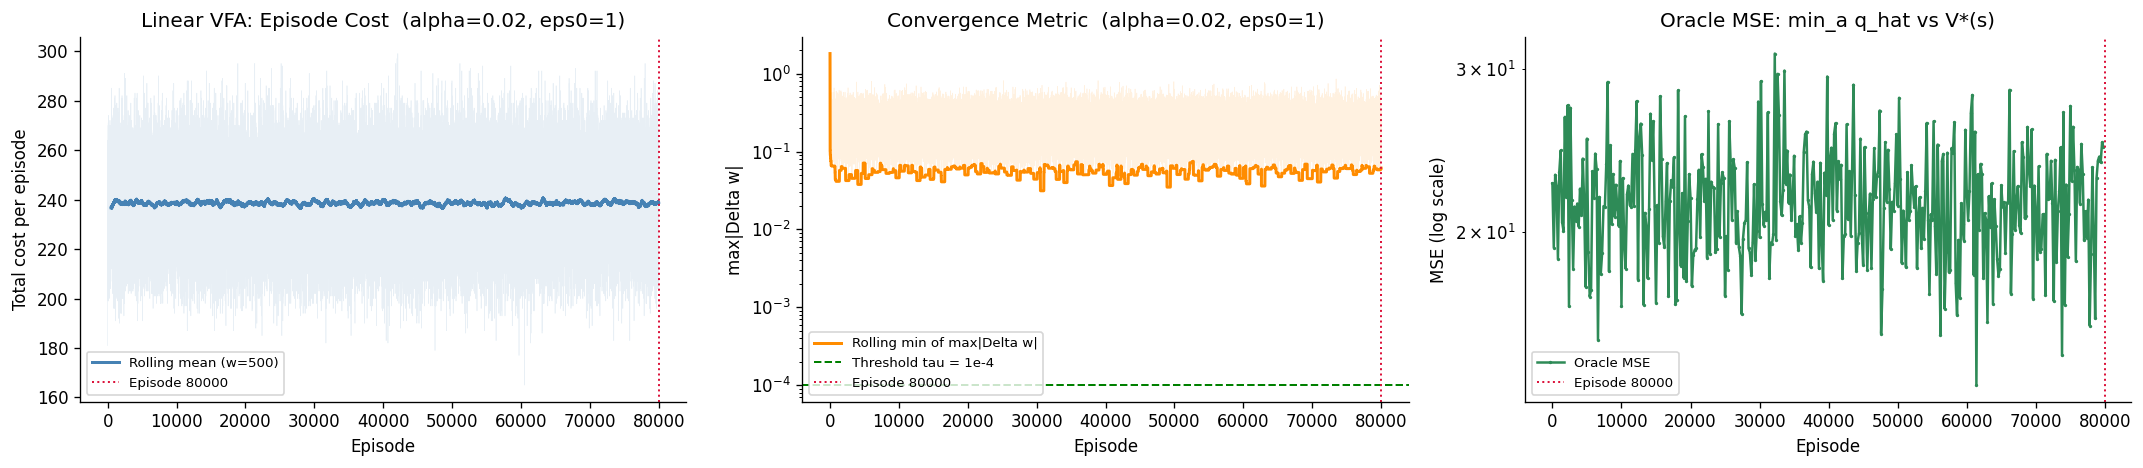

In [10]:
window = 500
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Left: per-episode cost + rolling mean
ax = axes[0]
sm = np.convolve(costs_vfa, np.ones(window) / window, mode="valid")
ax.plot(costs_vfa, color="steelblue", alpha=0.12, linewidth=0.4)
ax.plot(np.arange(window - 1, len(costs_vfa)), sm,
        color="steelblue", linewidth=1.8, label=f"Rolling mean (w={window})")
ax.axvline(conv_vfa, color="crimson", linestyle=":", linewidth=1.2,
           label=f"Convergence ep. {conv_vfa}")
ax.set_xlabel("Episode")
ax.set_ylabel("Total cost per episode")
ax.set_title(r"Linear VFA: Episode Cost  ($\omega=1.0,\ \varepsilon_0=1.0$)")
ax.legend(fontsize=8)

# Centre: max|Delta w| log scale — rolling minimum
ax = axes[1]
roll_min_dw = [np.min(dw_main[max(0, j - window):j + 1]) for j in range(len(dw_main))]
ax.semilogy(dw_main, alpha=0.12, color="darkorange", linewidth=0.4, label="raw")
ax.semilogy(roll_min_dw, color="darkorange", linewidth=1.8,
            label=f"Rolling min (w={window})")
ax.axhline(1e-3, color="green", linestyle="--", linewidth=1.2,
           label=r"Threshold $\tau = 10^{-3}$")
ax.axvline(conv_vfa, color="crimson", linestyle=":", linewidth=1.2,
           label=f"Convergence ep. {conv_vfa}")
ax.set_xlabel("Episode")
ax.set_ylabel("max|Δw| (log scale)")
ax.set_title(r"Linear VFA: Weight Convergence  ($\omega=1.0,\ \varepsilon_0=1.0$)")
ax.legend(fontsize=8)

# Right: oracle MSE
if mse_vfa:
    ep_idx, mse_vals = zip(*mse_vfa)
    ax = axes[2]
    ax.semilogy(ep_idx, mse_vals, color="seagreen", linewidth=1.5,
                marker=".", markersize=2, label="Oracle MSE")
    ax.axvline(conv_vfa, color="crimson", linestyle=":", linewidth=1.2,
               label=f"Convergence ep. {conv_vfa}")
    ax.set_xlabel("Episode")
    ax.set_ylabel("MSE (log scale)")
    ax.set_title(r"Oracle MSE: $\min_a \hat{q}(s,a,\mathbf{w})$ vs $V^*(s)$")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_vfa_convergence.pdf", bbox_inches="tight")
plt.show()

**Convergence interpretation.** The left panel shows the per-episode cost and its rolling mean (window = 500). The rolling mean stabilises as the behaviour policy approaches the optimal one. The centre panel shows max$|\Delta\mathbf{w}|$ on a log scale using a rolling minimum — the same visualisation as Task 1. Training stops once this drops below $\tau = 10^{-3}$ for 20 consecutive episodes. The right panel shows the oracle MSE: since the table-lookup feature gives zero approximation error, the oracle MSE converges to zero as the weights converge to the true Q-values.

## 6 — Optimal Policy

The greedy policy is extracted as:

$$\pi^*(s) = \arg\min_{a \in \mathcal{A}(s)} w[\text{idx}(s,a)]$$

with tie-breaking by the first lexicographic minimum. Because the weight is the Q-value, this is identical to the Task 1 policy extraction. States in REP\_1 and REP\_2 are excluded (action is forced: "continue maintenance"). The tables show the recommended action for each degradation-level pair $(x_1, x_2)$ by engineer location, compared to the PI oracle and to the Task 1 Q-Learning policy.

In [11]:
def print_policy_table(policy_dict, location, title=""):
    """Display policy as a DataFrame (rows=x1, cols=x2) for a given location."""
    rows = []
    for x1 in range(xi1 + 1):
        row = []
        for x2 in range(xi2 + 1):
            s = (x1, x2, location)
            row.append(policy_dict.get(s, "N/A"))
        rows.append(row)
    df = pd.DataFrame(
        rows,
        index   = [f"x1={i}" for i in range(xi1 + 1)],
        columns = [f"x2={j}" for j in range(xi2 + 1)],
    )
    print(f"\n{title}")
    print(df.to_string())


policy_VFA = extract_policy_vfa(w_main)
loc_names  = {DEPOT: "DEPOT", AT_1: "AT Machine 1", AT_2: "AT Machine 2"}

print("=" * 60)
print("LINEAR VFA Q-LEARNING POLICY  (omega=1.0, eps0=1.0)")
print("=" * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_VFA, loc, f"VFA — {name}")

print("\n" + "=" * 60)
print("POLICY ITERATION ORACLE  (Assignment 1 ground truth)")
print("=" * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_PI, loc, f"PI  — {name}")

# ── Match statistics vs PI ────────────────────────────────────────────────
total_nf = sum(1 for s in states if s[2] not in (REP_1, REP_2))
exact_pi = sum(1 for s in states
               if s[2] not in (REP_1, REP_2) and policy_VFA[s] == policy_PI[s])
match_pct_pi = 100.0 * exact_pi / total_nf

print(f"\nNon-forced states         : {total_nf}")
print(f"VFA exact matches vs PI   : {exact_pi}  ({match_pct_pi:.1f} %)")
print(f"VFA mismatches vs PI      : {total_nf - exact_pi}")

# ── Match statistics vs Task 1 Q-Learning ────────────────────────────────
if "policy_QL" in dir():
    exact_ql = sum(1 for s in states if policy_VFA[s] == policy_QL[s])
    print(f"VFA matches Task 1 QL     : {exact_ql}/{len(states)}  ({100*exact_ql/len(states):.1f} %)")

# ── Near-tie vs true mismatch analysis ───────────────────────────────────
NEAR_TIE_THRESHOLD = 0.05
near_tie_vfa, true_mismatch_vfa = [], []
for s in states:
    if s[2] in (REP_1, REP_2):
        continue
    if policy_VFA[s] == policy_PI[s]:
        continue
    s_idx     = states_indexes[s]
    flat_idxs = feasible_flat_global[s]
    q_vals    = np.sort(w_main[flat_idxs])
    gap       = float(q_vals[1] - q_vals[0]) if len(q_vals) > 1 else 0.0
    entry     = (s, policy_PI[s], policy_VFA[s], gap)
    if gap < NEAR_TIE_THRESHOLD:
        near_tie_vfa.append(entry)
    else:
        true_mismatch_vfa.append(entry)

print(f"Near-tie differences      : {len(near_tie_vfa)}  (Q-gap < {NEAR_TIE_THRESHOLD})")
print(f"True mismatches           : {len(true_mismatch_vfa)}")
if true_mismatch_vfa:
    print("\nTrue mismatches (PI action → VFA action, Q-gap):")
    for s, a_pi, a_vfa, gap in true_mismatch_vfa:
        print(f"  {s}: PI={a_pi:<22s} VFA={a_vfa:<22s} gap={gap:.4f}")

LINEAR VFA Q-LEARNING POLICY  (alpha=0.005, eps0=0.5)

VFA — DEPOT
          x2=0      x2=1      x2=2      x2=3      x2=4      x2=5      x2=6      x2=7
x1=0   nothing   nothing   nothing   nothing   nothing   nothing   nothing  travel_2
x1=1   nothing   nothing   nothing   nothing   nothing   nothing   nothing  travel_2
x1=2   nothing   nothing   nothing   nothing   nothing   nothing   nothing  travel_2
x1=3   nothing   nothing   nothing   nothing   nothing   nothing   nothing  travel_2
x1=4   nothing   nothing   nothing   nothing   nothing   nothing   nothing  travel_2
x1=5  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2

VFA — AT Machine 1
            x2=0        x2=1        x2=2        x2=3        x2=4        x2=5        x2=6          x2=7
x1=0     nothing     nothing     nothing     nothing     nothing     nothing     nothing  travel_depot
x1=1     nothing     nothing     nothing     nothing     nothing     nothing     nothing  travel_depot
x1=2     

## 7 — Hyperparameter Sensitivity Study

The only genuinely new hyperparameter relative to Task 1 is $\omega$ — the Robbins-Monro decay exponent in $\alpha_k = 1/N(s,a)^\omega$. We run a grid over $\omega \in \{1.00, 0.85, 0.70, 0.60\}$ and $\varepsilon_0 \in \{1.0, 0.5\}$ (8 configurations, $K = 80\,000$ episodes each), mirroring the Task 1 sensitivity section for direct comparability.

**Effect of $\omega$:** Values close to 1 give fast initial decay of $\alpha_k$, reducing oscillation; values closer to 0.5 keep rates higher for longer, potentially helping exploration but risking instability. $\omega = 1.0$ is the theoretically cleanest choice (harmonic series $\sum 1/N$ diverges; $\sum 1/N^2$ converges).

**Effect of $\varepsilon_0$:** Higher $\varepsilon_0$ slows the decay of the exploration rate, which helps early in training but may slow final convergence.

Results are saved to `hyperparam_vfa_results.json` after each configuration.

In [ ]:
VFA_RESULTS_FILE = "hyperparam_vfa_results.json"

CONFIGS_VFA = [
    {"alpha_power": 1.00, "epsilon_0": 1.0, "label": "w=1.00, e=1.0"},
    {"alpha_power": 1.00, "epsilon_0": 0.5, "label": "w=1.00, e=0.5"},
    {"alpha_power": 0.85, "epsilon_0": 1.0, "label": "w=0.85, e=1.0"},
    {"alpha_power": 0.85, "epsilon_0": 0.5, "label": "w=0.85, e=0.5"},
    {"alpha_power": 0.70, "epsilon_0": 1.0, "label": "w=0.70, e=1.0"},
    {"alpha_power": 0.70, "epsilon_0": 0.5, "label": "w=0.70, e=0.5"},
    #{"alpha_power": 0.60, "epsilon_0": 1.0, "label": "w=0.60, e=1.0"},
    #{"alpha_power": 0.60, "epsilon_0": 0.5, "label": "w=0.60, e=0.5"},
]

if os.path.exists(VFA_RESULTS_FILE):
    with open(VFA_RESULTS_FILE) as _f:
        vfa_study = _json.load(_f)
    _done = {r["label"] for r in vfa_study}
    print(f"Loaded {len(vfa_study)} saved result(s). Skipping: {_done}")
else:
    vfa_study = []
    _done     = set()

_total_nrep = sum(1 for s in states if s[2] not in (REP_1, REP_2))

for cfg in CONFIGS_VFA:
    if cfg["label"] in _done:
        print(f"[skip] {cfg['label']}")
        continue
    print(f"Running: {cfg['label']}")

    w_c, costs_c, dw_c, _, conv_c = linearVFA_qLearning(
        n_episodes        = 80_000,
        alpha_power       = cfg["alpha_power"],
        epsilon_0         = cfg["epsilon_0"],
        dw_tau            = 1e-3,
        consec_threshold  = 20,
        seed              = 42,
    )

    pol_c   = extract_policy_vfa(w_c)
    n_match = sum(1 for s in states
                  if s[2] not in (REP_1, REP_2) and pol_c[s] == policy_PI[s])
    match_pct  = 100.0 * n_match / _total_nrep
    final_cost = (float(np.mean(costs_c[-500:]))
                  if len(costs_c) >= 500 else float(np.mean(costs_c)))

    result = {
        "label"      : cfg["label"],
        "conv"       : conv_c,
        "costs"      : costs_c,
        "dw"         : dw_c,
        "match_pct"  : match_pct,
        "final_cost" : final_cost,
    }
    vfa_study.append(result)
    with open(VFA_RESULTS_FILE, "w") as _f:
        _json.dump(vfa_study, _f)

    print(f"  conv={conv_c:>6d}  match={match_pct:.1f}%  cost={final_cost:.2f}")
    print()

print("\nVFA hyperparameter study complete.")

# Summary table
df_vfa = pd.DataFrame([{
    "Configuration"    : r["label"],
    "Convergence ep."  : r["conv"],
    "Policy match (%)": f"{r['match_pct']:.1f}",
    "Final mean cost"  : f"{r['final_cost']:.3f}",
} for r in vfa_study])
print(df_vfa.to_string(index=False))

In [ ]:
import matplotlib.cm as _cm

n_configs = len(vfa_study)
n_cols_grid = 2
n_rows_grid = (n_configs + 1) // n_cols_grid

_cmap = plt.colormaps["tab10"].resampled(max(n_configs, 1))
window = 500

fig, axes = plt.subplots(n_rows_grid, n_cols_grid,
                         figsize=(14, n_rows_grid * 3), sharex=False)
axes = axes.flatten()

for i, r in enumerate(vfa_study):
    ax  = axes[i]
    dw  = r["dw"]
    col = _cmap(i)
    rolling_min = [np.min(dw[max(0, j - window): j + 1]) for j in range(len(dw))]
    ax.semilogy(dw, color=col, linewidth=0.4, alpha=0.2, label="raw")
    ax.semilogy(rolling_min, color=col, linewidth=1.8,
                label=f"rolling min (w={window})")
    ax.axhline(1e-3, color="green", ls="--", linewidth=1,
               label=r"$\tau=10^{-3}$")
    ax.axhline(1e-2, color="red",   ls="--", linewidth=1,
               label=r"$10^{-2}$")
    ax.set_title(
        f"{r['label']}  —  conv: {r['conv']}  |  match PI: {r['match_pct']:.1f}%",
        fontsize=9
    )
    ax.set_xlabel("Episode", fontsize=8)
    ax.set_ylabel("max|Δw|", fontsize=8)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    r"Linear VFA Q-Learning — max|$\Delta$w| per Episode ($\omega$, $\varepsilon_0$ grid)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig("fig_vfa_hyperparam_study.pdf", bbox_inches="tight")
plt.show()

## 8 — Task 1 vs Task 3: Summary of Differences

| Property | Q-Learning (Task 1) | Linear VFA (Task 3) |
|---|---|---|
| Value function | 2D Q-table: `Q[s_idx, a_idx]`, shape $(|S|, |A|)$ | Flat weight vector: `w[N_ACTIONS * s_idx + a_idx]`, length $|S| \times |A|$ |
| Approximation error | None (exact tabular representation) | None (table-lookup features give $\hat{q}(s,a,\mathbf{w}) = w[\text{idx}(s,a)]$ exactly) |
| Framework | Direct tabular update | SGD on parametric function $\hat{q}(s,a,\mathbf{w}) = \mathbf{x}(s,a)^\top\mathbf{w}$ |
| Feature vector | N/A | One-hot indicator $\mathbf{x}(s,a)$ of length $|S| \times |A|$ |
| Learning rate | Robbins-Monro per pair: $\alpha_k = 1/N(s,a)^\omega$ | Same: $\alpha_k = 1/N(s,a)^\omega$ (per-pair counter applies because each weight touched only when $(s,a)$ visited) |
| Hyperparameters | $\omega$, $\varepsilon_0$ | $\omega$, $\varepsilon_0$ (identical; $\omega$ is the only new parameter vs Task 1) |
| Initialisation | $Q(s,a) = 0$ feasible, $+\infty$ infeasible | $w[\text{idx}(s,a)] = 0$ feasible, $+\infty$ infeasible |
| Update per step | One entry `Q[s_idx, a_idx]` changes | One entry `w[idx(s,a)]` changes (one-hot gradient) |
| Convergence metric | max$|\Delta Q|$ per episode (feasible only) | max$|\Delta w|$ per episode (feasible only) — identical quantity |
| Convergence guarantee | Yes, under GLIE + Robbins-Monro | Yes (table-lookup features → zero approximation error → tabular theory applies) |

**Key observation:** With table-lookup indicator features, Task 3 is algebraically equivalent to Task 1. The only difference is that the Q-values are indexed through a flat weight vector instead of a 2D array, and the update is framed as stochastic gradient descent on a linear parametric function. This is explicitly the case described by the lecturer for OR/maintenance settings, where the state space is small enough that a one-to-one feature mapping is natural.

**Key observation.** Task 3 imposes a strong parametric constraint: $\hat{q}(s,a,\mathbf{w})$ must be a linear function of 14 features for all $(s,a)$ pairs. This means the true $q^*$ can only be recovered exactly if it lies in the span of the chosen feature vectors — which is generally not the case. The policy match percentage and oracle MSE therefore measure how well the 14-dimensional linear approximation can represent $q^*$, not just whether the learning algorithm has converged.